# EfficientNetB0 — Plant Disease Classification

This notebook implements EfficientNetB0 using transfer learning for
three-class plant disease classification:

- Healthy
- Powdery
- Rust

The model is evaluated using the project's standardized train,
validation, and test partitions.

## Experimental stages

1. Frozen EfficientNetB0 transfer-learning baseline
2. Controlled fine-tuning
3. Final validation-based configuration selection
4. Unseen test-set evaluation
5. Error analysis

In [1]:
import os
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

CLASS_NAMES = ["Healthy", "Powdery", "Rust"]

DATASET_DIR = Path("../dataset")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Create output directories if they do not exist

TRAIN_DIR = DATASET_DIR / "Train"
VAL_DIR = DATASET_DIR / "Validation"
TEST_DIR = DATASET_DIR / "Test"

print("Dataset:", DATASET_DIR.resolve())
print("Classes:", CLASS_NAMES)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Random seed: 42
Dataset: D:\Documents\Uni Project Work\plant-disease-classification\dataset
Classes: ['Healthy', 'Powdery', 'Rust']
Image size: (224, 224)
Batch size: 32


In [2]:
# Load train, validation, and test datasets

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Datasets loaded successfully.")

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.
Datasets loaded successfully.


In [3]:
print("Class names:", train_dataset.class_names)

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel value range:", tf.reduce_min(images).numpy(),
          "to", tf.reduce_max(images).numpy())

Class names: ['Healthy', 'Powdery', 'Rust']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel value range: 0.0 to 255.0


## EfficientNetB0 Input Pipeline

The images are loaded at 224 × 224 × 3 resolution.

EfficientNetB0 is used with ImageNet-pretrained weights. The input images
remain in their loaded 0–255 representation because the Keras EfficientNet
implementation includes the required input rescaling and normalization.

Training augmentation is applied only to the training dataset.
Validation and test data remain unaugmented.

In [4]:
# Training augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.10),
    ],
    name="data_augmentation"
)

print(data_augmentation)

<Sequential name=data_augmentation, built=False>


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_augmented = train_dataset.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=AUTOTUNE
)

train_dataset_augmented = train_dataset_augmented.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Training augmentation pipeline ready.")

Training augmentation pipeline ready.


In [6]:
# Load ImageNet-pretrained EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze the pretrained backbone for the baseline experiment
base_model.trainable = False

print("EfficientNetB0 loaded.")
print("Backbone trainable:", base_model.trainable)
print("Backbone output shape:", base_model.output_shape)

EfficientNetB0 loaded.
Backbone trainable: False
Backbone output shape: (None, 7, 7, 1280)


In [7]:
# Build the complete EfficientNetB0 classifier

inputs = keras.Input(shape=(224, 224, 3), name="input_image")

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.2, name="dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetB0_PlantDisease"
)

model.summary()

Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [8]:
# Parameter count

total_params = model.count_params()

trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_variables]
)

non_trainable_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 4,053,414
Trainable parameters: 3,843
Non-trainable parameters: 4,049,571


In [9]:
# Compile the frozen EfficientNetB0 baseline

LEARNING_RATE = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Learning rate:", LEARNING_RATE)
print("Optimizer: Adam")
print("Loss: SparseCategoricalCrossentropy")

Model compiled successfully.
Learning rate: 0.001
Optimizer: Adam
Loss: SparseCategoricalCrossentropy


In [10]:
# Callbacks for the frozen baseline

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

print("Callbacks configured.")

Callbacks configured.


In [11]:
# Train the frozen EfficientNetB0 baseline

EPOCHS_BASELINE = 20

start_time = time.time()

history_baseline = model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

baseline_training_time = time.time() - start_time

print(f"\nTraining time: {baseline_training_time:.2f} seconds")
print(f"Epochs actually completed: {len(history_baseline.history['loss'])}")

Epoch 1/20


d:\Documents\Uni Project Work\plant-disease-classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 332ms/step - accuracy: 0.7844 - loss: 0.6580 - val_accuracy: 0.9500 - val_loss: 0.3227 - learning_rate: 0.0010
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 297ms/step - accuracy: 0.9206 - loss: 0.3270 - val_accuracy: 0.9500 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 319ms/step - accuracy: 0.9402 - loss: 0.2505 - val_accuracy: 0.9500 - val_loss: 0.1848 - learning_rate: 0.0010
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - accuracy: 0.9629 - loss: 0.1901 - val_accuracy: 0.9667 - val_loss: 0.1396 - learning_rate: 0.0010
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 320ms/step - accuracy: 0.9576 - loss: 0.1731 - val_accuracy: 0.9833 - val_loss: 0.1302 - learning_rate: 0.0010
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 329ms/step - accuracy: 0.9592 - loss: 0.1542 - val_accuracy: 0.9667 - val_loss: 0.1058 - learning_rate: 0.0010
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 329ms/step - accuracy: 0.9667 - loss: 0.1415 - val_

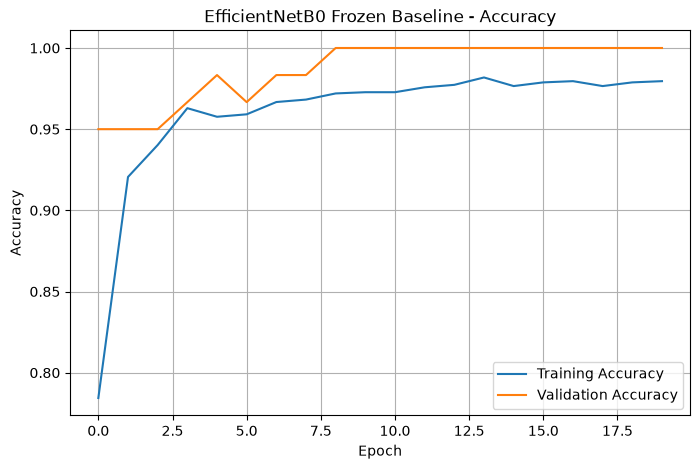

In [12]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Frozen Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

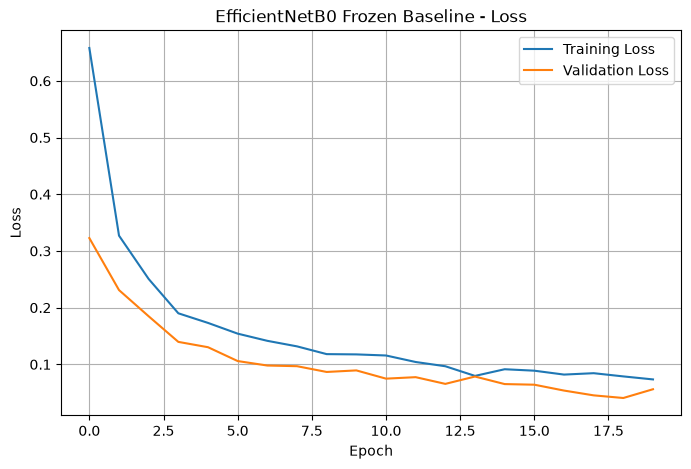

In [13]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_baseline.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Frozen Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Identify the best validation epoch

best_epoch = np.argmax(
    history_baseline.history["val_accuracy"]
) + 1

best_val_accuracy = max(
    history_baseline.history["val_accuracy"]
)

best_val_loss = min(
    history_baseline.history["val_loss"]
)

print("Best epoch by validation accuracy:", best_epoch)
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Lowest validation loss: {best_val_loss:.4f}")
print(f"Training time: {baseline_training_time:.2f} seconds")

Best epoch by validation accuracy: 9
Best validation accuracy: 1.0000
Lowest validation loss: 0.0407
Training time: 342.48 seconds


In [15]:
# Enable fine-tuning

base_model.trainable = True

# Freeze the earlier layers and fine-tune the later layers
fine_tune_from = 200

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True

print("Total backbone layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_from)

trainable_backbone = sum(
    layer.trainable for layer in base_model.layers
)

print("Trainable backbone layers:", trainable_backbone)

Total backbone layers: 238
Fine-tuning from layer: 200
Trainable backbone layers: 38


In [16]:
total_params_ft = model.count_params()

trainable_params_ft = np.sum(
    [np.prod(v.shape) for v in model.trainable_variables]
)

non_trainable_params_ft = total_params_ft - trainable_params_ft

print(f"Total parameters: {total_params_ft:,}")
print(f"Trainable parameters: {trainable_params_ft:,}")
print(f"Non-trainable parameters: {non_trainable_params_ft:,}")

Total parameters: 4,053,414
Trainable parameters: 2,054,547
Non-trainable parameters: 1,998,867


In [17]:
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Fine-tuning model compiled.")
print("Learning rate:", FINE_TUNE_LR)

Fine-tuning model compiled.
Learning rate: 1e-05


In [18]:
fine_tune_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

fine_tune_reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

print("Fine-tuning callbacks configured.")

Fine-tuning callbacks configured.


In [19]:
FINE_TUNE_EPOCHS = 15

start_time = time.time()

history_fine_tune = model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    verbose=1
)

fine_tune_training_time = time.time() - start_time

print(f"\nFine-tuning time: {fine_tune_training_time:.2f} seconds")
print(
    "Epochs actually completed:",
    len(history_fine_tune.history["loss"])
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 419ms/step - accuracy: 0.8949 - loss: 0.3122 - val_accuracy: 1.0000 - val_loss: 0.0502 - learning_rate: 1.0000e-05
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 0.9410 - loss: 0.2253 - val_accuracy: 0.9833 - val_loss: 0.0762 - learning_rate: 1.0000e-05
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 393ms/step - accuracy: 0.9380 - loss: 0.2167 - val_accuracy: 0.9833 - val_loss: 0.0911 - learning_rate: 1.0000e-05
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 30s 702ms/step - accuracy: 0.9546 - loss: 0.1835 - val_accuracy: 0.9667 - val_loss: 0.1230 - learning_rate: 2.0000e-06
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 28s 609ms/step - accuracy: 0.9592 - loss: 0.1702 - val_accuracy: 0.9500 - val_loss: 0.1400 - learning_rate: 2.0000e-06
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 370ms/step - accuracy: 0.9501 - loss: 0.1844 - val_accuracy: 0.9333 - val_loss: 0.1602 - learning_rate: 4.0000e-07

Fine-tuning time: 136.48 seconds
Epochs actually complete

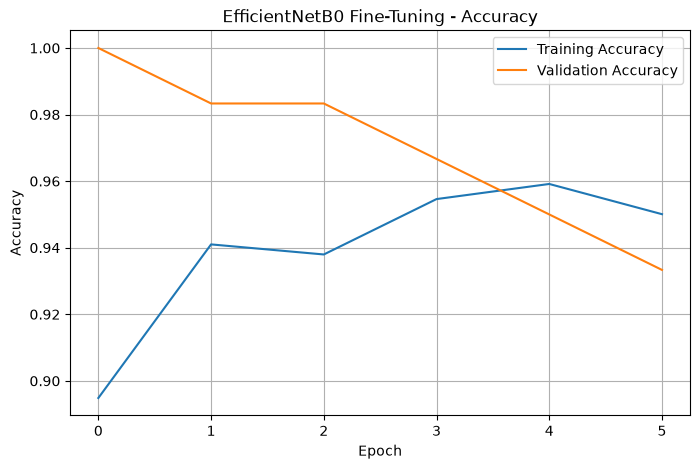

In [20]:
# Fine-tuning accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fine_tune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

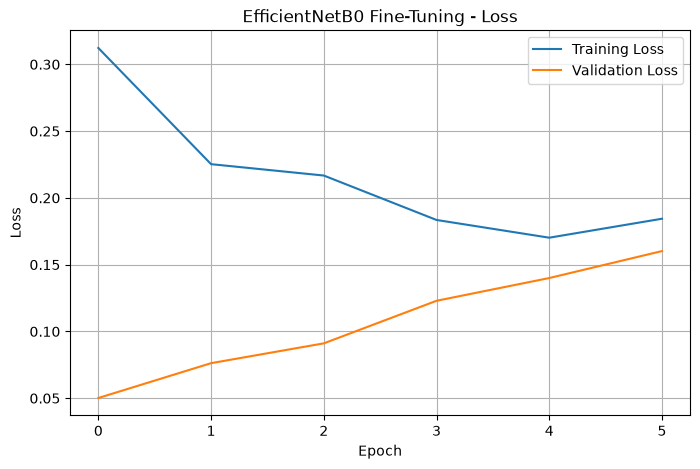

In [21]:
# Fine-tuning loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_fine_tune.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fine_tune.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
best_ft_epoch = np.argmin(
    history_fine_tune.history["val_loss"]
) + 1

best_ft_val_loss = min(
    history_fine_tune.history["val_loss"]
)

best_ft_val_accuracy = max(
    history_fine_tune.history["val_accuracy"]
)

print("EfficientNetB0 Fine-Tuning Summary")
print("-" * 40)
print("Best epoch by validation loss:", best_ft_epoch)
print(f"Best validation loss: {best_ft_val_loss:.4f}")
print(f"Best validation accuracy: {best_ft_val_accuracy:.4f}")
print(f"Fine-tuning time: {fine_tune_training_time:.2f} seconds")
print(
    "Epochs completed:",
    len(history_fine_tune.history["loss"])
)

EfficientNetB0 Fine-Tuning Summary
----------------------------------------
Best epoch by validation loss: 1
Best validation loss: 0.0502
Best validation accuracy: 1.0000
Fine-tuning time: 136.48 seconds
Epochs completed: 6


In [23]:
# EfficientNetB0 experiment comparison

experiment_comparison = pd.DataFrame([
    {
        "experiment_id": "ENB0-EXP-01",
        "configuration": "Frozen baseline",
        "best_val_accuracy": best_val_accuracy,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "epochs_completed": len(history_baseline.history["loss"]),
        "training_time_seconds": baseline_training_time,
        "training_time_minutes": baseline_training_time / 60,
    },
    {
        "experiment_id": "ENB0-EXP-02",
        "configuration": "Fine-tuned",
        "best_val_accuracy": best_ft_val_accuracy,
        "best_val_loss": best_ft_val_loss,
        "best_epoch": best_ft_epoch,
        "epochs_completed": len(history_fine_tune.history["loss"]),
        "training_time_seconds": fine_tune_training_time,
        "training_time_minutes": fine_tune_training_time / 60,
    }
])

experiment_comparison_path = (
    RESULTS_DIR / "efficientnetb0_experiment_comparison.csv"
)

experiment_comparison.to_csv(
    experiment_comparison_path,
    index=False
)

print("EfficientNetB0 Experiment Comparison")
print("=" * 50)

display(experiment_comparison)

print(
    f"\nSaved experiment comparison to:\n"
    f"{experiment_comparison_path.resolve()}"
)


EfficientNetB0 Experiment Comparison


,experiment_id,configuration,best_val_accuracy,best_val_loss,best_epoch,epochs_completed,training_time_seconds,training_time_minutes
0,ENB0-EXP-01,Frozen baseline,1.0,0.040671,9,20,342.477103,5.707952
1,ENB0-EXP-02,Fine-tuned,1.0,0.050165,1,6,136.482996,2.274717



Saved experiment comparison to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_experiment_comparison.csv


In [24]:
# Rebuild the selected frozen EfficientNetB0 configuration

base_model_final = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model_final.trainable = False

inputs_final = keras.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = base_model_final(inputs_final, training=False)
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)
x = layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs_final = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

final_model = keras.Model(
    inputs=inputs_final,
    outputs=outputs_final,
    name="EfficientNetB0_PlantDisease_Final"
)

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Final candidate model rebuilt.")
print("Backbone trainable:", base_model_final.trainable)

Final candidate model rebuilt.
Backbone trainable: False


In [25]:
# Save the best frozen-baseline weights

baseline_checkpoint = (
    MODELS_DIR / "efficientnetb0_frozen_best.weights.h5"
)

baseline_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    baseline_checkpoint,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

baseline_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [26]:
start_time = time.time()

history_final_baseline = final_model.fit(
    train_dataset_augmented,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        baseline_checkpoint_callback,
        baseline_early_stopping
    ],
    verbose=1
)

final_baseline_training_time = time.time() - start_time

print(
    f"Training time: {final_baseline_training_time:.2f} seconds"
)

Epoch 1/20


d:\Documents\Uni Project Work\plant-disease-classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.7458 - loss: 0.6890
Epoch 1: val_loss improved from None to 0.32372, saving model to ..\models\efficientnetb0_frozen_best.weights.h5

Epoch 1: finished saving model to ..\models\efficientnetb0_frozen_best.weights.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 372ms/step - accuracy: 0.7458 - loss: 0.6890 - val_accuracy: 0.9500 - val_loss: 0.3237
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9107 - loss: 0.3393
Epoch 2: val_loss improved from 0.32372 to 0.20032, saving model to ..\models\efficientnetb0_frozen_best.weights.h5

Epoch 2: finished saving model to ..\models\efficientnetb0_frozen_best.weights.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.9107 - loss: 0.3393 - val_accuracy: 0.9500 - val_loss: 0.2003
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.9418 - loss: 0.2511
Epoch 3: val_loss improved from 0.20032 to 0.16284, saving model to ..\models\efficientnetb0_frozen_best.weights.h5

Epoch

In [27]:
# Save final EfficientNetB0 training history

training_history = pd.DataFrame({
    "epoch": np.arange(
        1,
        len(history_final_baseline.history["loss"]) + 1
    ),
    "loss": history_final_baseline.history["loss"],
    "accuracy": history_final_baseline.history["accuracy"],
    "val_loss": history_final_baseline.history["val_loss"],
    "val_accuracy": history_final_baseline.history["val_accuracy"],
})

training_history_path = (
    RESULTS_DIR / "efficientnetb0_training_history.csv"
)

training_history.to_csv(
    training_history_path,
    index=False
)

print(
    f"Training history saved to:\n"
    f"{training_history_path.resolve()}"
)


Training history saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_training_history.csv


In [28]:
# Load the best frozen EfficientNetB0 weights

final_model.load_weights(
    baseline_checkpoint
)

print(
    f"Best frozen EfficientNetB0 weights loaded from:\n"
    f"{baseline_checkpoint.resolve()}"
)


Best frozen EfficientNetB0 weights loaded from:
D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_best.weights.h5


In [29]:
# Final evaluation on the untouched test set

test_loss, test_accuracy = final_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - accuracy: 0.9733 - loss: 0.0990
Test loss: 0.0990
Test accuracy: 0.9733


In [30]:
# Generate predictions for the test set

y_true = []
y_pred = []
y_prob = []

for images, labels in test_dataset:
    probabilities = final_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (150,)
Predictions: (150,)
Probabilities: (150, 3)


In [31]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [32]:
# Classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)


# Save classification report as CSV

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

classification_report_df = pd.DataFrame(
    report_dict
).transpose()

classification_report_path = (
    RESULTS_DIR / "efficientnetb0_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

print(
    f"\nClassification report saved to:\n"
    f"{classification_report_path.resolve()}"
)


              precision    recall  f1-score   support

     Healthy     0.9423    0.9800    0.9608        50
     Powdery     0.9792    0.9400    0.9592        50
        Rust     1.0000    1.0000    1.0000        50

    accuracy                         0.9733       150
   macro avg     0.9738    0.9733    0.9733       150
weighted avg     0.9738    0.9733    0.9733       150


Classification report saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_classification_report.csv


In [33]:
test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true, y_pred, average="weighted"
)

test_recall = recall_score(
    y_true, y_pred, average="weighted"
)

test_f1 = f1_score(
    y_true, y_pred, average="weighted"
)

test_roc_auc = roc_auc_score(
    y_true,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Weighted Precision: {test_precision:.4f}")
print(f"Weighted Recall:    {test_recall:.4f}")
print(f"Weighted F1:        {test_f1:.4f}")
print(f"Weighted ROC-AUC:   {test_roc_auc:.4f}")

Accuracy:          0.9733
Weighted Precision: 0.9738
Weighted Recall:    0.9733
Weighted F1:        0.9733
Weighted ROC-AUC:   0.9965


In [34]:
# Confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)


# Save confusion matrix as CSV

confusion_matrix_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

confusion_matrix_path = (
    RESULTS_DIR / "efficientnetb0_confusion_matrix.csv"
)

confusion_matrix_df.to_csv(
    confusion_matrix_path
)

print(
    f"\nConfusion matrix saved to:\n"
    f"{confusion_matrix_path.resolve()}"
)


Confusion Matrix:
[[49  1  0]
 [ 3 47  0]
 [ 0  0 50]]

Confusion matrix saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_confusion_matrix.csv


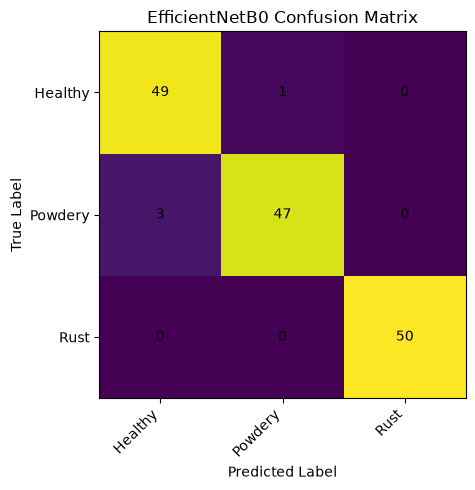

In [35]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Confusion Matrix")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [36]:
# Final EfficientNetB0 test results

final_results = pd.DataFrame([{
    "model": "EfficientNetB0",
    "configuration": "Frozen ImageNet backbone",

    "test_samples": len(y_true),

    "test_loss": test_loss,
    "accuracy": test_accuracy,
    "weighted_precision": test_precision,
    "weighted_recall": test_recall,
    "weighted_f1": test_f1,
    "weighted_roc_auc": test_roc_auc,

    "best_val_accuracy": best_val_accuracy,
    "best_val_loss": best_val_loss,
    "best_val_epoch": best_epoch,

    "epochs_completed": len(
        history_final_baseline.history["loss"]
    ),

    "training_time_seconds": final_baseline_training_time,
    "training_time_minutes": final_baseline_training_time / 60,

    "total_parameters": final_model.count_params(),

    "trainable_parameters": sum(
        np.prod(v.shape)
        for v in final_model.trainable_variables
    ),
}])

final_results_path = (
    RESULTS_DIR / "efficientnetb0_final_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("EfficientNetB0 Final Test Results")
print("-" * 40)

display(final_results)

print(
    f"\nFinal results saved to:\n"
    f"{final_results_path.resolve()}"
)


EfficientNetB0 Final Test Results
----------------------------------------


,model,configuration,test_samples,test_loss,accuracy,weighted_precision,weighted_recall,weighted_f1,weighted_roc_auc,best_val_accuracy,best_val_loss,best_val_epoch,epochs_completed,training_time_seconds,training_time_minutes,total_parameters,trainable_parameters
0,EfficientNetB0,Frozen ImageNet backbone,150,0.098953,0.973333,0.973825,0.973333,0.973323,0.996467,1.0,0.040671,9,20,401.983498,6.699725,4053414,3843



Final results saved to:
D:\Documents\Uni Project Work\plant-disease-classification\results\efficientnetb0_final_results.csv


In [37]:
# Save final EfficientNetB0 model

FINAL_MODEL_PATH = (
    MODELS_DIR / "efficientnetb0_frozen_final.keras"
)

final_model.save(FINAL_MODEL_PATH)

print(
    f"Final EfficientNetB0 model saved to:\n"
    f"{FINAL_MODEL_PATH.resolve()}"
)


Final EfficientNetB0 model saved to:
D:\Documents\Uni Project Work\plant-disease-classification\models\efficientnetb0_frozen_final.keras
